In [43]:
import pandas as pd
from nilearn import datasets
from nilearn.image import coord_transform
import numpy as np
import nibabel as nib

In [36]:
!ls /Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/group_level_analysis/backgroundEff

RPV.nii
ResMS.nii
SPM.mat
beta_0001.nii
cluster_stats_threshold_voxels_40.xlsx
con_0001.nii
edited_cluster_stats_threshold_voxels_40.xlsx
mask.nii
second_lev_background_eff_code.m
second_lev_background_eff_job.m
spmT_0001.nii
spm_img_fixed.nii
stats.xlsx
stats_significant_clusters.xlsx
thresholded_image.nii
~$stats_significant_clusters.xlsx


In [94]:
# Load the uploaded Excel file
file_path = '/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/group_level_analysis/predictionErr/stats_significant_clusters.xlsx'
clusters = pd.read_excel(file_path)

In [95]:
clusters.head()

,cluster_p_FWE_corr,cluster_p_FDR_corr,cluster_size,cluster_p_unc_,peak_T,peak_p_unc_,x,y,z
0,0.0,0.0,1236,6.97,4.59,0,20,-12,40
1,0.0,0.0,588,6.96,4.58,0,-16,22,16
2,0.0,0.0,1635,6.68,4.48,0,-40,-20,64
3,0.0,0.0,343,6.49,4.41,0,-18,-4,58
4,0.0,0.0,630,6.39,4.37,0,-20,-50,28


In [96]:
clusters.columns

Index(['cluster_p_FWE_corr', 'cluster_p_FDR_corr', 'cluster_size',
       'cluster_p_unc_', 'peak_T', 'peak_p_unc_', 'x', 'y', 'z'],
      dtype='object')

In [97]:
# Fetch the Harvard-Oxford cortical and subcortical atlases
atlas_cortical = datasets.fetch_atlas_harvard_oxford('cort-maxprob-thr25-1mm')
atlas_subcortical = datasets.fetch_atlas_harvard_oxford('sub-maxprob-thr25-1mm')

atlas_cortical_filename = atlas_cortical.filename
atlas_subcortical_filename = atlas_subcortical.filename

atlas_cortical_labels = atlas_cortical.labels
atlas_subcortical_labels = atlas_subcortical.labels


In [98]:
# Define a function to find the region for given coordinates
def find_region(x, y, z):
    # Load cortical atlas image
    atlas_cortical_img = nib.load(atlas_cortical_filename)
    affine_cortical = atlas_cortical_img.affine
    # Convert MNI coordinates to voxel coordinates for cortical atlas
    voxel_coords_cortical = coord_transform(x, y, z, np.linalg.inv(affine_cortical))
    voxel_coords_cortical = tuple(np.round(voxel_coords_cortical).astype(int))
    # Get the cortical atlas label at the voxel coordinates
    label_index_cortical = atlas_cortical_img.get_fdata()[voxel_coords_cortical]
    
    if label_index_cortical:  # If a label is found in the cortical atlas
        return atlas_cortical_labels[int(label_index_cortical)]
    
    # Load subcortical atlas image
    atlas_subcortical_img = nib.load(atlas_subcortical_filename)
    affine_subcortical = atlas_subcortical_img.affine
    # Convert MNI coordinates to voxel coordinates for subcortical atlas
    voxel_coords_subcortical = coord_transform(x, y, z, np.linalg.inv(affine_subcortical))
    voxel_coords_subcortical = tuple(np.round(voxel_coords_subcortical).astype(int))
    # Get the subcortical atlas label at the voxel coordinates
    label_index_subcortical = atlas_subcortical_img.get_fdata()[voxel_coords_subcortical]
    
    if label_index_subcortical:  # If a label is found in the subcortical atlas
        return atlas_subcortical_labels[int(label_index_subcortical)]
    
    return 'Unknown Region'

In [99]:
# Apply the function to the dataframe
clusters['Region'] = clusters.apply(lambda row: find_region(row['x'], row['y'], row['z']), axis=1)

# Display the resulting dataframe
# import ace_tools as tools; tools.display_dataframe_to_user(name="SPM Data with Regions", dataframe=df)

# Display the first few rows to the user to confirm
clusters.head()

,cluster_p_FWE_corr,cluster_p_FDR_corr,cluster_size,cluster_p_unc_,peak_T,peak_p_unc_,x,y,z,Region
0,0.0,0.0,1236,6.97,4.59,0,20,-12,40,Right Cerebral White Matter
1,0.0,0.0,588,6.96,4.58,0,-16,22,16,Left Cerebral White Matter
2,0.0,0.0,1635,6.68,4.48,0,-40,-20,64,Precentral Gyrus
3,0.0,0.0,343,6.49,4.41,0,-18,-4,58,Left Cerebral White Matter
4,0.0,0.0,630,6.39,4.37,0,-20,-50,28,Left Cerebral White Matter


In [100]:
# Save the DataFrame to a CSV file
clusters.to_csv('/Users/proghani/Documents/personal/local_thesis_folder/fMRI/main/bids_fmri_data/group_level_analysis/predictionErr/clusters_with_labels.csv', index=False)

**Ventromedial Prefrontal Cortex (vmPFC):** 

The vmPFC is generally located in the medial part of the frontal lobe. In the Harvard-Oxford atlas, the "Frontal Medial Cortex" and "Subcallosal Cortex" might be the closest approximations.
- Frontal Medial Cortex
- Subcallosal Cortex  

**Dorsomedial Prefrontal Cortex (dmPFC):**

The dmPFC is located in the upper part of the medial prefrontal cortex. The Harvard-Oxford atlas label "Superior Frontal Gyrus" (medial part) can approximate this region.
- Superior Frontal Gyrus (medial segment)

**Substantia Nigra/Ventral Tegmental Area (SN/VTA):**

The substantia nigra and VTA are part of the midbrain and may not be explicitly labeled in the Harvard-Oxford cortical atlas since it primarily focuses on cortical regions. However, the Harvard-Oxford subcortical atlas includes regions in the midbrain that could approximate this area.
- Substantia Nigra

In [47]:
for label in atlas_cortical_labels:
    print(label)

Background
Frontal Pole
Insular Cortex
Superior Frontal Gyrus
Middle Frontal Gyrus
Inferior Frontal Gyrus, pars triangularis
Inferior Frontal Gyrus, pars opercularis
Precentral Gyrus
Temporal Pole
Superior Temporal Gyrus, anterior division
Superior Temporal Gyrus, posterior division
Middle Temporal Gyrus, anterior division
Middle Temporal Gyrus, posterior division
Middle Temporal Gyrus, temporooccipital part
Inferior Temporal Gyrus, anterior division
Inferior Temporal Gyrus, posterior division
Inferior Temporal Gyrus, temporooccipital part
Postcentral Gyrus
Superior Parietal Lobule
Supramarginal Gyrus, anterior division
Supramarginal Gyrus, posterior division
Angular Gyrus
Lateral Occipital Cortex, superior division
Lateral Occipital Cortex, inferior division
Intracalcarine Cortex
Frontal Medial Cortex
Juxtapositional Lobule Cortex (formerly Supplementary Motor Cortex)
Subcallosal Cortex
Paracingulate Gyrus
Cingulate Gyrus, anterior division
Cingulate Gyrus, posterior division
Precuneo

In [55]:
from nilearn.image import math_img
from nilearn import datasets, plotting

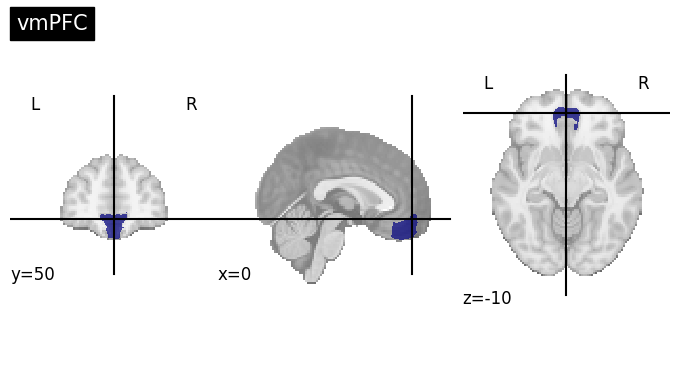

In [56]:
vmPFC_index = atlas_cortical_labels.index('Frontal Medial Cortex')
# dmPFC_index = atlas_cortical_labels.index('Superior Frontal Gyrus') 
# sn_index = atlas_subcortical_labels.index('Substantia Nigra')

# Extract the ROIs
vmPFC_mask = math_img(f'img == {vmPFC_index}', img=atlas_cortical.maps)
# dmPFC_mask = math_img(f'img == {dmPFC_index}', img=atlas_cortical.maps)
# sn_mask = math_img(f'img == {sn_index}', img=atlas_subcortical.maps)

# Visualize the ROIs
plotting.plot_roi(vmPFC_mask, title='vmPFC', display_mode='ortho', cut_coords=(0, 50, -10))
# plotting.plot_roi(dmPFC_mask, title='dmPFC', display_mode='ortho', cut_coords=(0, 50, 30))
# plotting.plot_roi(sn_mask, title='SN/VTA', display_mode='ortho', cut_coords=(0, -15, -10))
plotting.show()